# STDA2102: Soft Computing (EL1) - Assignment 2
## Module 2: Artificial Neural Networks (ANNs) (Complete 10 Practical Exercises)

**Course Code:** STDA2102  
**Student Name:** Manish Kumar  
**Practical Evaluation:** Implementation (15), Understanding (10), Code Quality (10), Analysis (10), Record (5) -> Total 50 Pts

---

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
print('Module environment configured successfully.')

Module environment configured successfully.


## Practical 1: Practical 2.1: Basic Working of an Artificial Neuron

```
Practical 2.1: Basic Working of an Artificial Neuron
Course: Soft Computing (EL1) - STDA2102 | Module 2: Artificial Neural Networks

Aim:
To understand and implement the basic working of an artificial neuron using Python.

Theory:
Proposed by Warren McCulloch and Walter Pitts (1943), the artificial neuron is the fundamental
computational unit of ANNs. It mimics the biological neuron:
- Dendrites receive input signals (x1, x2, ..., xn)
- Synapses scale signals by weights (w1, w2, ..., wn)
- Cell body (Soma) aggregates the inputs and subtracts a threshold θ:
      Net Input = ∑_{i=1}^n w_i * x_i
- Axon outputs firing decision based on a threshold activation function:
      y = 1 if Net Input >= θ else 0
```

PRACTICAL 2.1: McCulloch-Pitts Artificial Neuron

Truth Table Verification:
 x1   |  x2   |  AND Output  |  OR Output  
------------------------------------------
  0   |   0   |      0       |      0      
  0   |   1   |      0       |      1      
  1   |   0   |      0       |      1      
  1   |   1   |      1       |      1      

NOT Gate Verification:
 x1   |  NOT Output 
--------------------
  0   |      1      
  1   |      0      


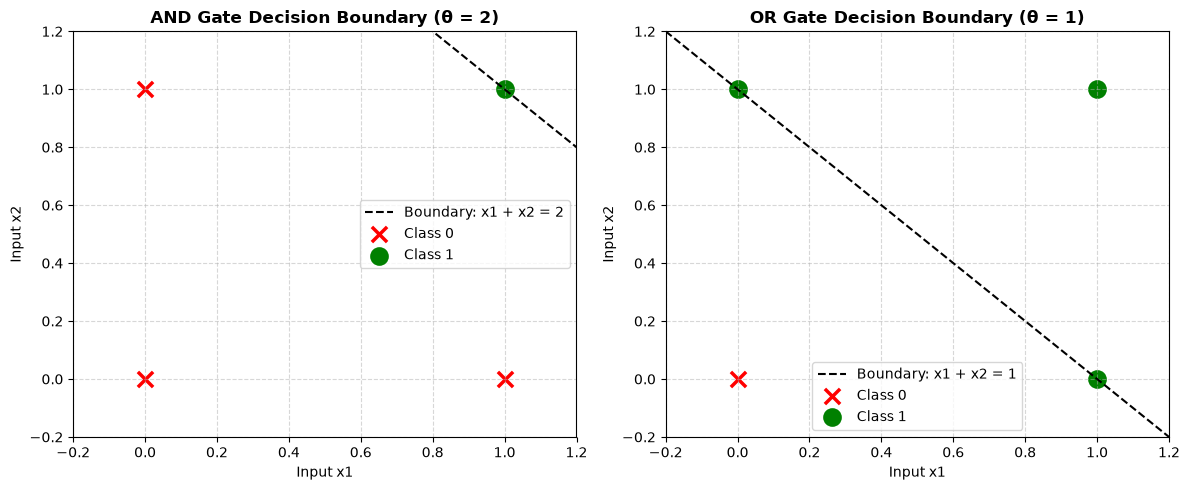


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_2_Neural_Networks/../output_plots/mod2_ex01_artificial_neuron.png
[✓] Practical 2.1 completed successfully.



In [2]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

class McCullochPittsNeuron:
    def __init__(self, weights, threshold):
        self.weights = np.array(weights)
        self.threshold = threshold

    def activate(self, inputs):
        net = np.dot(inputs, self.weights)
        return 1 if net >= self.threshold else 0

def run_practical_2_1():
    print("=" * 60)
    print("PRACTICAL 2.1: McCulloch-Pitts Artificial Neuron")
    print("=" * 60)

    # 1. Implementation of AND Gate: inputs x1, x2 ∈ {0, 1}
    # Weights = [1, 1], Threshold θ = 2
    and_neuron = McCullochPittsNeuron(weights=[1, 1], threshold=2)

    # 2. Implementation of OR Gate: inputs x1, x2 ∈ {0, 1}
    # Weights = [1, 1], Threshold θ = 1
    or_neuron = McCullochPittsNeuron(weights=[1, 1], threshold=1)

    # 3. Implementation of NOT Gate: input x1 ∈ {0, 1}
    # Weight = -1, Threshold θ = 0
    not_neuron = McCullochPittsNeuron(weights=[-1], threshold=0)

    inputs_2d = [(0, 0), (0, 1), (1, 0), (1, 1)]

    print("\nTruth Table Verification:")
    print(f"{'x1':^5} | {'x2':^5} | {'AND Output':^12} | {'OR Output':^12}")
    print("-" * 42)
    and_outs, or_outs = [], []
    for x1, x2 in inputs_2d:
        y_and = and_neuron.activate([x1, x2])
        y_or = or_neuron.activate([x1, x2])
        and_outs.append(y_and)
        or_outs.append(y_or)
        print(f"{x1:^5} | {x2:^5} | {y_and:^12} | {y_or:^12}")

    print("\nNOT Gate Verification:")
    print(f"{'x1':^5} | {'NOT Output':^12}")
    print("-" * 20)
    for x in [0, 1]:
        print(f"{x:^5} | {not_neuron.activate([x]):^12}")

    # Visualization of Decision Boundaries for AND and OR
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # AND Decision Boundary: w1*x1 + w2*x2 = theta -> x1 + x2 = 2 -> x2 = 2 - x1
    x_line = np.linspace(-0.2, 1.2, 100)
    ax1.plot(x_line, 2 - x_line, 'k--', label='Boundary: x1 + x2 = 2')
    for (x1, x2), y in zip(inputs_2d, and_outs):
        marker = 'o' if y == 1 else 'x'
        color = 'green' if y == 1 else 'red'
        ax1.scatter(x1, x2, color=color, s=120, marker=marker, linewidths=2.5,
                    label=f'Class {y}' if f'Class {y}' not in ax1.get_legend_handles_labels()[1] else '')
    ax1.set_title("AND Gate Decision Boundary (θ = 2)", fontweight='bold')
    ax1.set_xlabel("Input x1")
    ax1.set_ylabel("Input x2")
    ax1.set_xlim(-0.2, 1.2)
    ax1.set_ylim(-0.2, 1.2)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend()

    # OR Decision Boundary: x1 + x2 = 1 -> x2 = 1 - x1
    ax2.plot(x_line, 1 - x_line, 'k--', label='Boundary: x1 + x2 = 1')
    for (x1, x2), y in zip(inputs_2d, or_outs):
        marker = 'o' if y == 1 else 'x'
        color = 'green' if y == 1 else 'red'
        ax2.scatter(x1, x2, color=color, s=120, marker=marker, linewidths=2.5,
                    label=f'Class {y}' if f'Class {y}' not in ax2.get_legend_handles_labels()[1] else '')
    ax2.set_title("OR Gate Decision Boundary (θ = 1)", fontweight='bold')
    ax2.set_xlabel("Input x1")
    ax2.set_ylabel("Input x2")
    ax2.set_xlim(-0.2, 1.2)
    ax2.set_ylim(-0.2, 1.2)
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod2_ex01_artificial_neuron.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 2.1 completed successfully.\n")

if True:
    run_practical_2_1()

## Practical 2: Practical 2.2: Weighted Sum of Inputs and Bias

```
Practical 2.2: Weighted Sum of Inputs and Bias
Course: Soft Computing (EL1) - STDA2102 | Module 2: Artificial Neural Networks

Aim:
To implement the weighted sum of inputs and bias used in an artificial neuron using Python.

Theory:
In modern neural architectures, each neuron calculates an affine transformation:
    z = w^T · x + b = (∑_{i=1}^n w_i * x_i) + b

Where:
- x = [x1, x2, ..., xn]^T is the input feature vector.
- w = [w1, w2, ..., wn]^T is the synaptic weight vector defining orientation of the hyperplane.
- b is the scalar bias, acting as an adjustable intercept that allows the decision boundary
  to shift freely without being constrained to pass through the origin.
```

PRACTICAL 2.2: Weighted Sum and Bias Implementation
Weights W:
[ 0.8 -1.2]
Bias b: 0.5

Input Vector X and Computed Linear Activation Z = W^T*X + b:
 Sample  |    x1    |    x2    |  Weighted Sum (z) 
--------------------------------------------------
   1     |     1.50 |     2.00 |             -0.700
   2     |     3.00 |     4.50 |             -2.500
   3     |    -1.00 |     2.50 |             -3.300
   4     |     0.00 |     1.00 |             -0.700


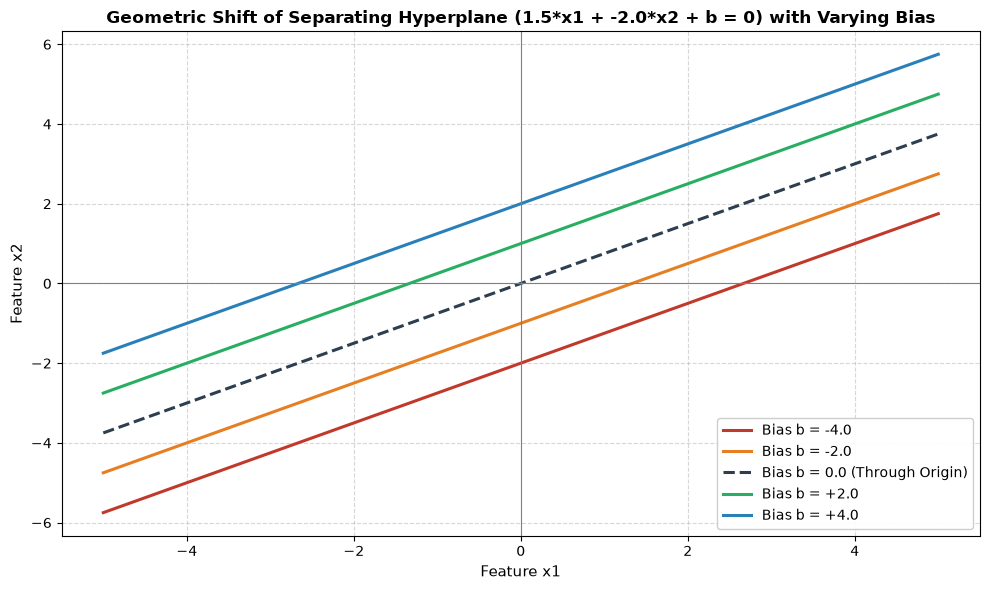


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_2_Neural_Networks/../output_plots/mod2_ex02_weighted_sum_and_bias.png
[✓] Practical 2.2 completed successfully.



In [3]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def compute_affine_transformation(X, W, b):
    """
    Vectorized computation of weighted sum + bias:
    X: shape (m, n) where m is batch size, n is feature dimension
    W: shape (n, 1)
    b: scalar or shape (1,)
    Returns Z = X @ W + b
    """
    return np.dot(X, W) + b

def run_practical_2_2():
    print("=" * 60)
    print("PRACTICAL 2.2: Weighted Sum and Bias Implementation")
    print("=" * 60)

    # 1. Concrete Numerical Demonstration
    X_sample = np.array([
        [1.5, 2.0],
        [3.0, 4.5],
        [-1.0, 2.5],
        [0.0, 1.0]
    ])
    W = np.array([[0.8], [-1.2]])
    bias = 0.5

    Z = compute_affine_transformation(X_sample, W, bias)

    print(f"Weights W:\n{W.ravel()}")
    print(f"Bias b: {bias}")
    print("\nInput Vector X and Computed Linear Activation Z = W^T*X + b:")
    print(f"{'Sample':^8} | {'x1':^8} | {'x2':^8} | {'Weighted Sum (z)':^18}")
    print("-" * 50)
    for i in range(len(X_sample)):
        print(f"{i+1:^8} | {X_sample[i, 0]:8.2f} | {X_sample[i, 1]:8.2f} | {Z[i, 0]:18.3f}")

    # 2. Geometric Effect of Bias Visualization
    # Hyperplane equation: w1*x1 + w2*x2 + b = 0 => x2 = -(w1/w2)*x1 - (b/w2)
    x1_vals = np.linspace(-5, 5, 200)
    w1, w2 = 1.5, -2.0
    biases = [-4.0, -2.0, 0.0, 2.0, 4.0]

    plt.figure(figsize=(10, 6))
    colors = ['#c0392b', '#e67e22', '#2c3e50', '#27ae60', '#2980b9']

    for b_val, c in zip(biases, colors):
        x2_vals = -(w1 / w2) * x1_vals - (b_val / w2)
        style = '--' if b_val == 0.0 else '-'
        label = f'Bias b = {b_val:+.1f}' if b_val != 0.0 else 'Bias b = 0.0 (Through Origin)'
        plt.plot(x1_vals, x2_vals, color=c, linestyle=style, linewidth=2.2, label=label)

    plt.title(f"Geometric Shift of Separating Hyperplane ({w1}*x1 + {w2}*x2 + b = 0) with Varying Bias",
              fontsize=12, fontweight='bold')
    plt.xlabel("Feature x1", fontsize=11)
    plt.ylabel("Feature x2", fontsize=11)
    plt.axhline(0, color='gray', linewidth=0.8)
    plt.axvline(0, color='gray', linewidth=0.8)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='lower right', framealpha=0.95)
    plt.tight_layout()

    plot_path = os.path.join(OUTPUT_DIR, "mod2_ex02_weighted_sum_and_bias.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 2.2 completed successfully.\n")

if True:
    run_practical_2_2()

## Practical 3: Practical 2.3: Activation Functions and Their Derivatives

```
Practical 2.3: Activation Functions and Their Derivatives
Course: Soft Computing (EL1) - STDA2102 | Module 2: Artificial Neural Networks

Aim:
To implement and visualize Sigmoid, Tanh, and ReLU activation functions using Python.

Theory:
Non-linear activation functions allow multilayer neural networks to learn complex non-linear mappings:
1. Sigmoid (Logistic):
       σ(z) = 1 / (1 + e^(-z)) ∈ (0, 1)
       Derivative: σ'(z) = σ(z) * (1 - σ(z))
2. Hyperbolic Tangent (Tanh):
       tanh(z) = (e^z - e^(-z)) / (e^z + e^(-z)) ∈ (-1, 1)
       Derivative: tanh'(z) = 1 - tanh^2(z)
3. Rectified Linear Unit (ReLU):
       f(z) = max(0, z)
       Derivative: f'(z) = 1 if z > 0 else 0
4. Leaky ReLU:
       f(z) = z if z > 0 else α*z (α = 0.01)
```

PRACTICAL 2.3: Activation Functions and Derivatives
  z    |  Sigmoid   |    Tanh    |    ReLU    |  dSigmoid  |   dTanh   
-----------------------------------------------------------------
 -3.0  |   0.0474   |  -0.9951   |   0.0000   |   0.0452   |   0.0099  
 -1.0  |   0.2689   |  -0.7616   |   0.0000   |   0.1966   |   0.4200  
 0.0   |   0.5000   |   0.0000   |   0.0000   |   0.2500   |   1.0000  
 1.0   |   0.7311   |   0.7616   |   1.0000   |   0.1966   |   0.4200  
 3.0   |   0.9526   |   0.9951   |   3.0000   |   0.0452   |   0.0099  


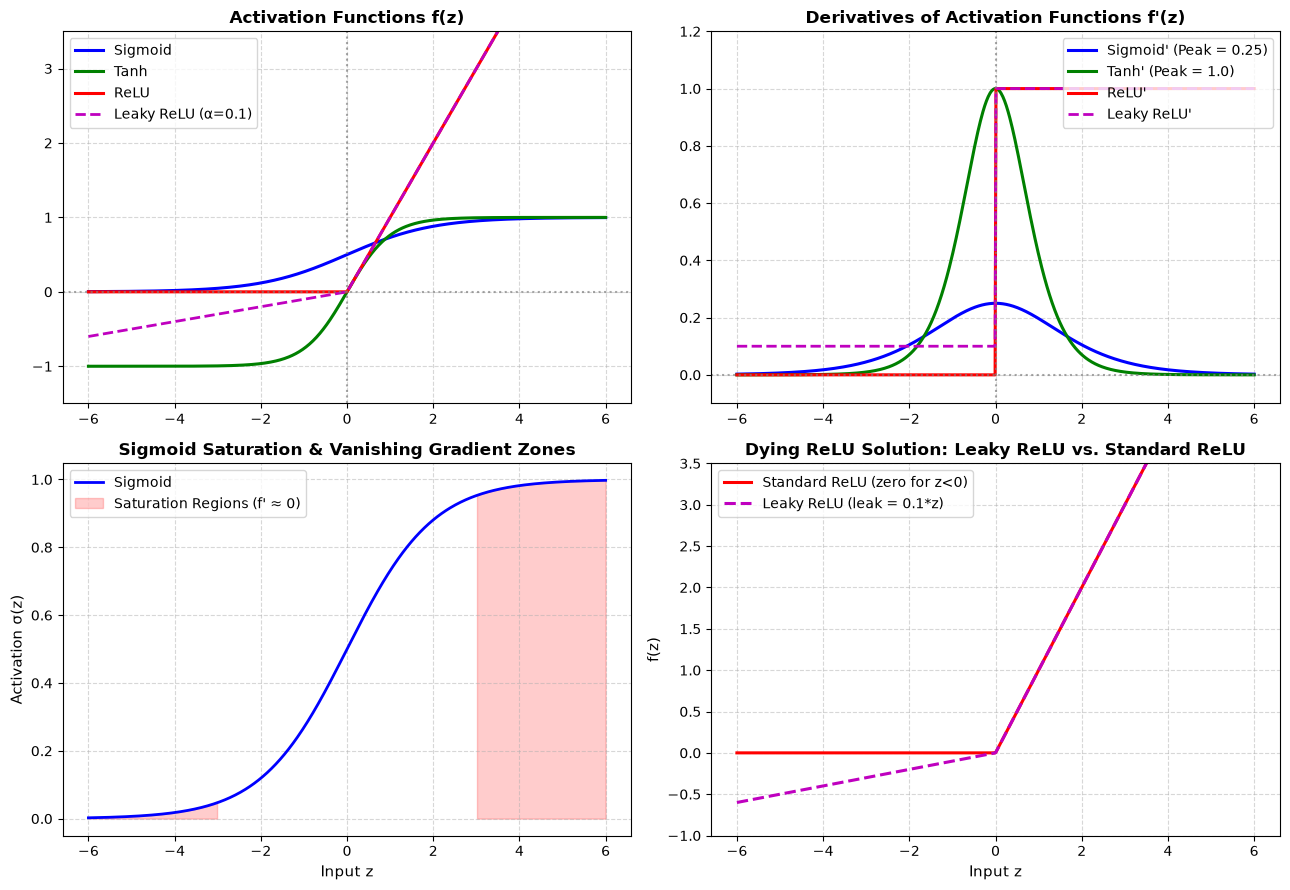


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_2_Neural_Networks/../output_plots/mod2_ex03_activation_functions.png
[✓] Practical 2.3 completed successfully.



In [4]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Sigmoid
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1.0 - s)

# 2. Tanh
def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1.0 - np.tanh(z)**2

# 3. ReLU
def relu(z):
    return np.maximum(0.0, z)

def relu_derivative(z):
    return np.where(z > 0, 1.0, 0.0)

# 4. Leaky ReLU
def leaky_relu(z, alpha=0.1):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_derivative(z, alpha=0.1):
    return np.where(z > 0, 1.0, alpha)

def run_practical_2_3():
    print("=" * 60)
    print("PRACTICAL 2.3: Activation Functions and Derivatives")
    print("=" * 60)

    z = np.linspace(-6, 6, 600)

    # Numerical outputs at critical test points
    test_pts = [-3.0, -1.0, 0.0, 1.0, 3.0]
    print(f"{'z':^6} | {'Sigmoid':^10} | {'Tanh':^10} | {'ReLU':^10} | {'dSigmoid':^10} | {'dTanh':^10}")
    print("-" * 65)
    for p in test_pts:
        print(f"{p:^6.1f} | {sigmoid(p):^10.4f} | {tanh(p):^10.4f} | {relu(p):^10.4f} | {sigmoid_derivative(p):^10.4f} | {tanh_derivative(p):^10.4f}")

    # Visualization: 2x2 grid (Functions and Derivatives)
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # Top-Left: Activation Functions
    axes[0, 0].plot(z, sigmoid(z), 'b-', linewidth=2.2, label='Sigmoid')
    axes[0, 0].plot(z, tanh(z), 'g-', linewidth=2.2, label='Tanh')
    axes[0, 0].plot(z, relu(z), 'r-', linewidth=2.2, label='ReLU')
    axes[0, 0].plot(z, leaky_relu(z), 'm--', linewidth=2.0, label='Leaky ReLU (α=0.1)')
    axes[0, 0].set_title("Activation Functions f(z)", fontsize=12, fontweight='bold')
    axes[0, 0].set_ylim(-1.5, 3.5)
    axes[0, 0].axhline(0, color='gray', linestyle=':', alpha=0.7)
    axes[0, 0].axvline(0, color='gray', linestyle=':', alpha=0.7)
    axes[0, 0].grid(True, linestyle='--', alpha=0.5)
    axes[0, 0].legend(loc='upper left')

    # Top-Right: Derivatives f'(z)
    axes[0, 1].plot(z, sigmoid_derivative(z), 'b-', linewidth=2.2, label="Sigmoid' (Peak = 0.25)")
    axes[0, 1].plot(z, tanh_derivative(z), 'g-', linewidth=2.2, label="Tanh' (Peak = 1.0)")
    axes[0, 1].plot(z, relu_derivative(z), 'r-', linewidth=2.2, label="ReLU'")
    axes[0, 1].plot(z, leaky_relu_derivative(z), 'm--', linewidth=2.0, label="Leaky ReLU'")
    axes[0, 1].set_title("Derivatives of Activation Functions f'(z)", fontsize=12, fontweight='bold')
    axes[0, 1].set_ylim(-0.1, 1.2)
    axes[0, 1].axhline(0, color='gray', linestyle=':', alpha=0.7)
    axes[0, 1].axvline(0, color='gray', linestyle=':', alpha=0.7)
    axes[0, 1].grid(True, linestyle='--', alpha=0.5)
    axes[0, 1].legend(loc='upper right')

    # Bottom-Left: Sigmoid Saturation & Vanishing Gradient demonstration
    axes[1, 0].plot(z, sigmoid(z), 'b-', linewidth=2, label='Sigmoid')
    axes[1, 0].fill_between(z[z < -3], sigmoid(z[z < -3]), color='red', alpha=0.2, label='Saturation Regions (f\' ≈ 0)')
    axes[1, 0].fill_between(z[z > 3], sigmoid(z[z > 3]), color='red', alpha=0.2)
    axes[1, 0].set_title("Sigmoid Saturation & Vanishing Gradient Zones", fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel("Input z", fontsize=11)
    axes[1, 0].set_ylabel("Activation σ(z)", fontsize=11)
    axes[1, 0].grid(True, linestyle='--', alpha=0.5)
    axes[1, 0].legend(loc='upper left')

    # Bottom-Right: ReLU vs Leaky ReLU (Dying ReLU mitigation)
    axes[1, 1].plot(z, relu(z), 'r-', linewidth=2.2, label='Standard ReLU (zero for z<0)')
    axes[1, 1].plot(z, leaky_relu(z, 0.1), 'm--', linewidth=2.2, label='Leaky ReLU (leak = 0.1*z)')
    axes[1, 1].set_title("Dying ReLU Solution: Leaky ReLU vs. Standard ReLU", fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel("Input z", fontsize=11)
    axes[1, 1].set_ylabel("f(z)", fontsize=11)
    axes[1, 1].set_ylim(-1.0, 3.5)
    axes[1, 1].grid(True, linestyle='--', alpha=0.5)
    axes[1, 1].legend(loc='upper left')

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod2_ex03_activation_functions.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 2.3 completed successfully.\n")

if True:
    run_practical_2_3()

## Practical 4: Practical 2.4: Simple Single-Layer Neural Network (Perceptron Learning Rule)

```
Practical 2.4: Simple Single-Layer Neural Network (Perceptron Learning Rule)
Course: Soft Computing (EL1) - STDA2102 | Module 2: Artificial Neural Networks

Aim:
To create a simple single-layer neural network using Python.

Theory:
A Single-Layer Perceptron (Frank Rosenblatt, 1958) is capable of classifying linearly separable patterns.
The network model computes:
    z = w1*x1 + w2*x2 + b
    y_pred = 1 if z >= 0 else 0

Perceptron Learning Algorithm:
For each sample (x, y_true):
    Error e = y_true - y_pred
    w = w + η * e * x
    b = b + η * e
where η is the learning rate.
```

PRACTICAL 2.4: Single-Layer Perceptron Implementation
Perceptron converged at epoch 26!

Trained Weights: [0.26985288 0.21219361]
Trained Bias: -1.2000
Classification Accuracy: 100.00%



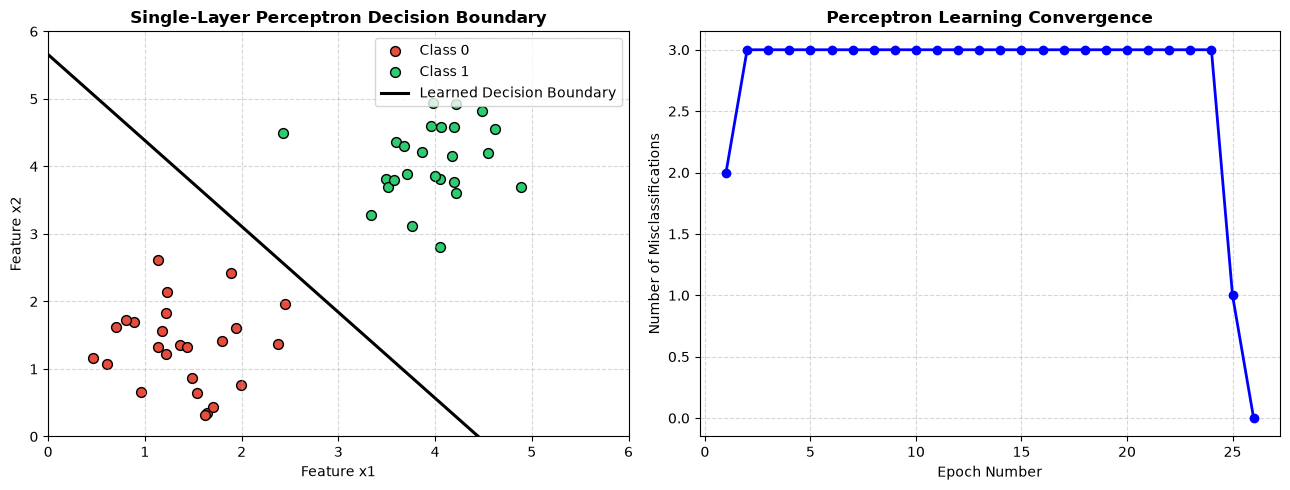

[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_2_Neural_Networks/../output_plots/mod2_ex04_single_layer_network.png
[✓] Practical 2.4 completed successfully.



In [5]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

class Perceptron:
    def __init__(self, lr=0.1, max_epochs=50):
        self.lr = lr
        self.max_epochs = max_epochs
        self.weights = None
        self.bias = None
        self.history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.max_epochs):
            total_errors = 0
            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = 1 if linear_output >= 0 else 0
                error = y[i] - y_pred

                if error != 0:
                    self.weights += self.lr * error * X[i]
                    self.bias += self.lr * error
                    total_errors += 1

            self.history.append((self.weights.copy(), self.bias, total_errors))
            if total_errors == 0:
                print(f"Perceptron converged at epoch {epoch + 1}!")
                break

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, 0)

def run_practical_2_4():
    print("=" * 60)
    print("PRACTICAL 2.4: Single-Layer Perceptron Implementation")
    print("=" * 60)

    # Linearly separable synthetic 2D dataset
    np.random.seed(42)
    # Class 0: Center (2, 2)
    X0 = np.random.randn(25, 2) * 0.6 + np.array([1.5, 1.5])
    y0 = np.zeros(25, dtype=int)
    # Class 1: Center (4, 4)
    X1 = np.random.randn(25, 2) * 0.6 + np.array([4.0, 4.0])
    y1 = np.ones(25, dtype=int)

    X = np.vstack([X0, X1])
    y = np.concatenate([y0, y1])

    # Train Perceptron
    clf = Perceptron(lr=0.05, max_epochs=30)
    clf.fit(X, y)

    print(f"\nTrained Weights: {clf.weights}")
    print(f"Trained Bias: {clf.bias:.4f}")

    y_pred = clf.predict(X)
    accuracy = np.mean(y_pred == y) * 100.0
    print(f"Classification Accuracy: {accuracy:.2f}%\n")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Plot 1: Decision Boundary
    ax1.scatter(X0[:, 0], X0[:, 1], color='#e74c3c', s=50, label='Class 0', edgecolors='k')
    ax1.scatter(X1[:, 0], X1[:, 1], color='#2ecc71', s=50, label='Class 1', edgecolors='k')

    x_line = np.linspace(0, 6, 200)
    # w1*x1 + w2*x2 + b = 0 -> x2 = -(w1*x1 + b)/w2
    if clf.weights[1] != 0:
        y_line = -(clf.weights[0] * x_line + clf.bias) / clf.weights[1]
        ax1.plot(x_line, y_line, 'k-', linewidth=2.2, label='Learned Decision Boundary')

    ax1.set_title("Single-Layer Perceptron Decision Boundary", fontweight='bold')
    ax1.set_xlabel("Feature x1")
    ax1.set_ylabel("Feature x2")
    ax1.set_xlim(0, 6)
    ax1.set_ylim(0, 6)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend()

    # Plot 2: Training Convergence (Errors vs Epoch)
    errors_per_epoch = [h[2] for h in clf.history]
    ax2.plot(range(1, len(errors_per_epoch) + 1), errors_per_epoch, 'bo-', linewidth=2)
    ax2.set_title("Perceptron Learning Convergence", fontweight='bold')
    ax2.set_xlabel("Epoch Number")
    ax2.set_ylabel("Number of Misclassifications")
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod2_ex04_single_layer_network.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 2.4 completed successfully.\n")

if True:
    run_practical_2_4()

## Practical 5: Practical 2.5: Multilayer Perceptron (MLP) with Input, Hidden, and Output Layers

```
Practical 2.5: Multilayer Perceptron (MLP) with Input, Hidden, and Output Layers
Course: Soft Computing (EL1) - STDA2102 | Module 2: Artificial Neural Networks

Aim:
To create a Multilayer Perceptron (MLP) with input, hidden, and output layers using Keras/TensorFlow.

Theory:
A Multilayer Perceptron (MLP) overcomes the linear separability limitations of single-layer perceptrons
(Minsky & Papert, 1969) by inserting one or more hidden layers with non-linear activation functions.
Architecture:
- Input Layer: Accepts d features (e.g. x1, x2).
- Hidden Layer(s): Applies affine transformation followed by non-linear activation:
      h = ReLU(W1 * x + b1)
- Output Layer: Maps hidden representations to target predictions:
      y_hat = Sigmoid(W2 * h + b2)
Universal Approximation Theorem guarantees that an MLP with at least one non-linear hidden layer
can approximate any continuous function.
```

PRACTICAL 2.5: Multilayer Perceptron (MLP) Architecture
Keras framework available: True



--- Keras MLP Model Summary ---


Model: "Multilayer_Perceptron_XOR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)


Non-linear XOR Truth Table & MLP Predictions:
 x1   |  x2   |  y_true  |  y_pred (prob)  | Rounded 
----------------------------------------------------
  0   |   0   |    0     |     0.0001      |    0    
  0   |   1   |    1     |     1.0000      |    1    
  1   |   0   |    1     |     1.0000      |    1    
  1   |   1   |    0     |     0.0000      |    0    


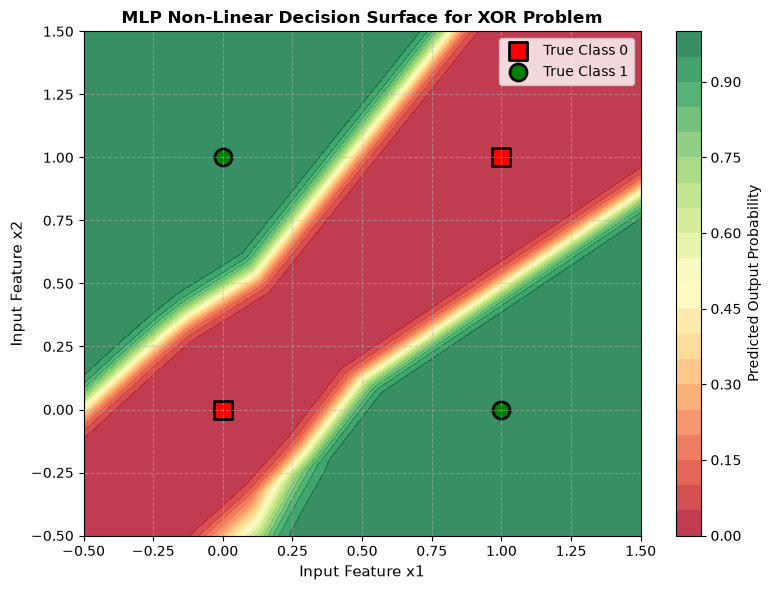


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_2_Neural_Networks/../output_plots/mod2_ex05_mlp_keras.png
[✓] Practical 2.5 completed successfully.



In [6]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

try:
    import keras
    from keras import layers
    HAS_KERAS = True
except Exception as e:
    HAS_KERAS = False

def run_practical_2_5():
    print("=" * 60)
    print("PRACTICAL 2.5: Multilayer Perceptron (MLP) Architecture")
    print("=" * 60)
    print(f"Keras framework available: {HAS_KERAS}")

    # Dataset: Non-linear XOR Problem (Cannot be solved by single-layer perceptron)
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
    y = np.array([[0], [1], [1], [0]], dtype=np.float32)

    if HAS_KERAS:
        # Define MLP Model using Keras Sequential API
        model = keras.Sequential([
            layers.Input(shape=(2,), name="Input_Layer"),
            layers.Dense(units=8, activation="relu", name="Hidden_Layer_1"),
            layers.Dense(units=4, activation="relu", name="Hidden_Layer_2"),
            layers.Dense(units=1, activation="sigmoid", name="Output_Layer")
        ], name="Multilayer_Perceptron_XOR")

        # Compile model
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.08),
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )

        print("\n--- Keras MLP Model Summary ---")
        model.summary()

        # Train model
        history = model.fit(X, y, epochs=250, verbose=0)
        predictions = model.predict(X, verbose=0)
    else:
        # Pure NumPy MLP for XOR fallback
        np.random.seed(42)
        W1 = np.random.randn(2, 4)
        b1 = np.zeros((1, 4))
        W2 = np.random.randn(4, 1)
        b2 = np.zeros((1, 1))

        def sig(z): return 1 / (1 + np.exp(-z))
        for _ in range(5000):
            z1 = X @ W1 + b1
            a1 = np.maximum(0, z1) # relu
            z2 = a1 @ W2 + b2
            a2 = sig(z2)
            # Backprop
            d2 = a2 - y
            dW2 = a1.T @ d2
            db2 = np.sum(d2, axis=0, keepdims=True)
            d1 = (d2 @ W2.T) * (z1 > 0)
            dW1 = X.T @ d1
            db1 = np.sum(d1, axis=0, keepdims=True)
            W1 -= 0.1 * dW1
            b1 -= 0.1 * db1
            W2 -= 0.1 * dW2
            b2 -= 0.1 * db2
        predictions = sig(np.maximum(0, X @ W1 + b1) @ W2 + b2)

    print("\nNon-linear XOR Truth Table & MLP Predictions:")
    print(f"{'x1':^5} | {'x2':^5} | {'y_true':^8} | {'y_pred (prob)':^15} | {'Rounded':^8}")
    print("-" * 52)
    for i in range(4):
        p = float(predictions[i][0])
        print(f"{int(X[i, 0]):^5} | {int(X[i, 1]):^5} | {int(y[i, 0]):^8} | {p:^15.4f} | {round(p):^8}")

    # Plot Decision Surface
    x_grid = np.linspace(-0.5, 1.5, 200)
    y_grid = np.linspace(-0.5, 1.5, 200)
    XX, YY = np.meshgrid(x_grid, y_grid)
    grid_points = np.c_[XX.ravel(), YY.ravel()]

    if HAS_KERAS:
        ZZ = model.predict(grid_points, verbose=0).reshape(XX.shape)
    else:
        ZZ = sig(np.maximum(0, grid_points @ W1 + b1) @ W2 + b2).reshape(XX.shape)

    plt.figure(figsize=(8, 6))
    contour = plt.contourf(XX, YY, ZZ, levels=20, cmap='RdYlGn', alpha=0.8)
    plt.colorbar(contour, label='Predicted Output Probability')

    # Overlay ground truth XOR points
    for i in range(4):
        color = 'green' if y[i, 0] == 1 else 'red'
        marker = 'o' if y[i, 0] == 1 else 's'
        plt.scatter(X[i, 0], X[i, 1], c=color, s=150, marker=marker, edgecolors='black',
                    linewidths=2, label=f"True Class {int(y[i, 0])}" if i < 2 else "")

    plt.title("MLP Non-Linear Decision Surface for XOR Problem", fontsize=12, fontweight='bold')
    plt.xlabel("Input Feature x1", fontsize=11)
    plt.ylabel("Input Feature x2", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.tight_layout()

    plot_path = os.path.join(OUTPUT_DIR, "mod2_ex05_mlp_keras.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 2.5 completed successfully.\n")

if True:
    run_practical_2_5()

## Practical 6: Practical 2.6: Gradient Descent Optimization (Batch, Stochastic, and Mini-Batch)

```
Practical 2.6: Gradient Descent Optimization (Batch, Stochastic, and Mini-Batch)
Course: Soft Computing (EL1) - STDA2102 | Module 2: Artificial Neural Networks

Aim:
To apply Gradient Descent for updating the weights of a simple neural network during training.

Theory:
Gradient Descent iteratively updates model parameters θ in the direction of steepest descent
of the loss function J(θ):
    θ_{t+1} = θ_t - η * ∇_θ J(θ_t)

Three Primary Variants:
1. Batch Gradient Descent (BGD): Uses the entire dataset of N samples per step.
   Smooth, stable convergence, but computationally expensive for large datasets.
2. Stochastic Gradient Descent (SGD): Uses a single training instance (N=1) per update step.
   Fast and can escape local minima, but exhibits high variance/oscillation.
3. Mini-Batch Gradient Descent (MBGD): Uses mini-batches (e.g., size B=16 or 32).
   Achieves balance between computational efficiency of vectorized ops and regularized convergence.
```

PRACTICAL 2.6: Gradient Descent Algorithms Comparison
Ground Truth Model: y = 4.0 + 3.0 * x
Batch GD Estimated:       bias=3.480, weight=3.452 | Final Loss=0.1619
Stochastic GD Estimated:  bias=4.052, weight=3.029 | Final Loss=0.1182
Mini-Batch GD Estimated:  bias=4.041, weight=2.997 | Final Loss=0.1168


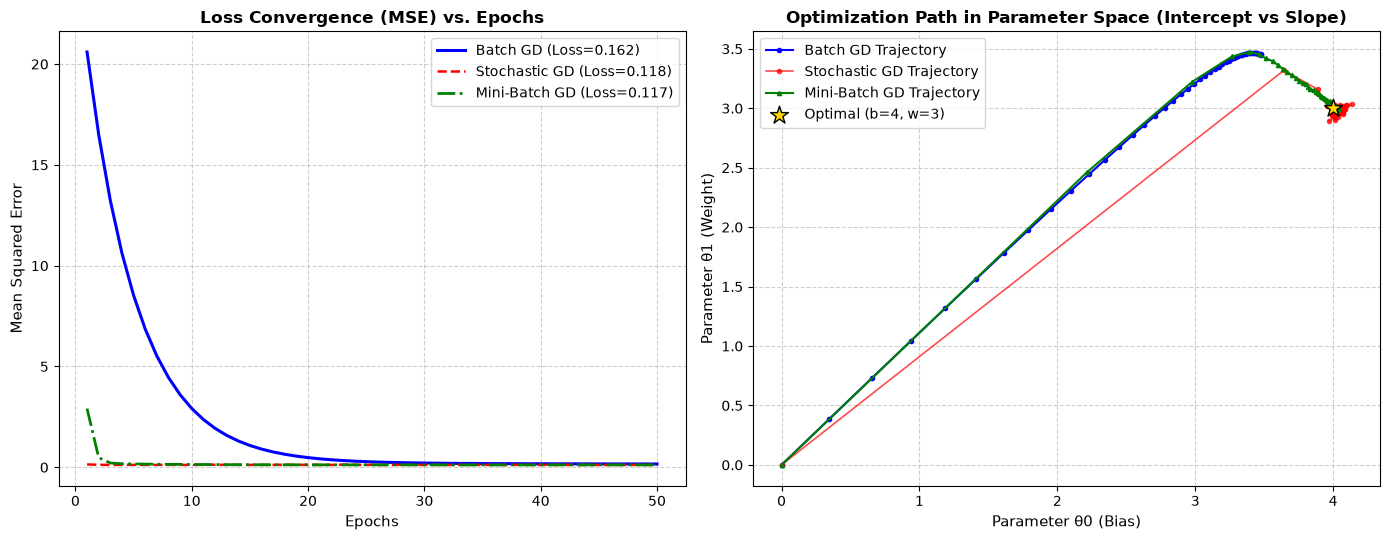


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_2_Neural_Networks/../output_plots/mod2_ex06_gradient_descent.png
[✓] Practical 2.6 completed successfully.



In [7]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def generate_regression_data(n_samples=200):
    np.random.seed(42)
    X = 2 * np.random.rand(n_samples, 1)
    # Ground truth: y = 4 + 3*X + noise
    y = 4 + 3 * X + np.random.randn(n_samples, 1) * 0.5
    return X, y

def compute_loss(X_b, y, theta):
    m = len(y)
    preds = X_b.dot(theta)
    return (1.0 / (2 * m)) * np.sum((preds - y) ** 2)

def run_practical_2_6():
    print("=" * 60)
    print("PRACTICAL 2.6: Gradient Descent Algorithms Comparison")
    print("=" * 60)

    X, y = generate_regression_data(n_samples=200)
    X_b = np.c_[np.ones((len(X), 1)), X]  # add bias feature x0 = 1
    m = len(y)

    lr = 0.05
    n_epochs = 50

    # 1. Batch Gradient Descent
    theta_bgd = np.array([[0.0], [0.0]])
    bgd_losses = []
    bgd_thetas = [theta_bgd.copy()]
    for _ in range(n_epochs):
        gradients = (1.0 / m) * X_b.T.dot(X_b.dot(theta_bgd) - y)
        theta_bgd -= lr * gradients
        bgd_thetas.append(theta_bgd.copy())
        bgd_losses.append(compute_loss(X_b, y, theta_bgd))

    # 2. Stochastic Gradient Descent (SGD)
    theta_sgd = np.array([[0.0], [0.0]])
    sgd_losses = []
    sgd_thetas = [theta_sgd.copy()]
    for epoch in range(n_epochs):
        indices = np.random.permutation(m)
        for i in indices:
            xi = X_b[i:i+1]
            yi = y[i:i+1]
            gradients = xi.T.dot(xi.dot(theta_sgd) - yi)
            theta_sgd -= (lr * 0.5) * gradients
        sgd_thetas.append(theta_sgd.copy())
        sgd_losses.append(compute_loss(X_b, y, theta_sgd))

    # 3. Mini-batch Gradient Descent
    theta_mb = np.array([[0.0], [0.0]])
    mb_losses = []
    batch_size = 20
    mb_thetas = [theta_mb.copy()]
    for epoch in range(n_epochs):
        shuffled = np.random.permutation(m)
        X_shuff = X_b[shuffled]
        y_shuff = y[shuffled]
        for i in range(0, m, batch_size):
            xb_i = X_shuff[i:i+batch_size]
            yb_i = y_shuff[i:i+batch_size]
            gradients = (1.0 / len(yb_i)) * xb_i.T.dot(xb_i.dot(theta_mb) - yb_i)
            theta_mb -= lr * gradients
        mb_thetas.append(theta_mb.copy())
        mb_losses.append(compute_loss(X_b, y, theta_mb))

    print(f"Ground Truth Model: y = 4.0 + 3.0 * x")
    print(f"Batch GD Estimated:       bias={theta_bgd[0, 0]:.3f}, weight={theta_bgd[1, 0]:.3f} | Final Loss={bgd_losses[-1]:.4f}")
    print(f"Stochastic GD Estimated:  bias={theta_sgd[0, 0]:.3f}, weight={theta_sgd[1, 0]:.3f} | Final Loss={sgd_losses[-1]:.4f}")
    print(f"Mini-Batch GD Estimated:  bias={theta_mb[0, 0]:.3f}, weight={theta_mb[1, 0]:.3f} | Final Loss={mb_losses[-1]:.4f}")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

    # Plot 1: Loss curves
    epochs_range = range(1, n_epochs + 1)
    ax1.plot(epochs_range, bgd_losses, 'b-', linewidth=2.2, label=f'Batch GD (Loss={bgd_losses[-1]:.3f})')
    ax1.plot(epochs_range, sgd_losses, 'r--', linewidth=1.8, label=f'Stochastic GD (Loss={sgd_losses[-1]:.3f})')
    ax1.plot(epochs_range, mb_losses, 'g-.', linewidth=2.0, label=f'Mini-Batch GD (Loss={mb_losses[-1]:.3f})')
    ax1.set_title("Loss Convergence (MSE) vs. Epochs", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Epochs", fontsize=11)
    ax1.set_ylabel("Mean Squared Error", fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # Plot 2: Trajectory in Parameter Space (b, w)
    bgd_t = np.array(bgd_thetas)[:, :, 0]
    sgd_t = np.array(sgd_thetas)[:, :, 0]
    mb_t = np.array(mb_thetas)[:, :, 0]

    ax2.plot(bgd_t[:, 0], bgd_t[:, 1], 'bo-', label='Batch GD Trajectory', linewidth=1.5, markersize=3)
    ax2.plot(sgd_t[:, 0], sgd_t[:, 1], 'r.-', label='Stochastic GD Trajectory', alpha=0.7, linewidth=1.2)
    ax2.plot(mb_t[:, 0], mb_t[:, 1], 'g^-', label='Mini-Batch GD Trajectory', linewidth=1.5, markersize=3)
    ax2.scatter(4.0, 3.0, color='gold', s=180, marker='*', edgecolors='black', label='Optimal (b=4, w=3)', zorder=5)
    ax2.set_title("Optimization Path in Parameter Space (Intercept vs Slope)", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Parameter θ0 (Bias)", fontsize=11)
    ax2.set_ylabel("Parameter θ1 (Weight)", fontsize=11)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod2_ex06_gradient_descent.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 2.6 completed successfully.\n")

if True:
    run_practical_2_6()

## Practical 7: Practical 2.7: Backpropagation Algorithm from Scratch

```
Practical 2.7: Backpropagation Algorithm from Scratch
Course: Soft Computing (EL1) - STDA2102 | Module 2: Artificial Neural Networks

Aim:
To understand and implement the basic concept of Backpropagation for training a neural network.

Theory:
Backpropagation (Rumelhart, Hinton, & Williams, 1986) calculates the gradient of the loss function
with respect to each weight using the Chain Rule of calculus:
1. Forward Pass:
       z1 = W1 * x + b1,   a1 = σ(z1)
       z2 = W2 * a1 + b2,  a2 = σ(z2) (y_hat)
       Loss L = 0.5 * (y - y_hat)^2
2. Backward Pass (Output Layer):
       δ2 = ∂L / ∂z2 = (y_hat - y) * σ'(z2)
       ∂L / ∂W2 = a1^T * δ2,   ∂L / ∂b2 = δ2
3. Backward Pass (Hidden Layer):
       δ1 = ∂L / ∂z1 = (δ2 * W2^T) * σ'(z1)
       ∂L / ∂W1 = x^T * δ1,    ∂L / ∂b1 = δ1
4. Weight Updates:
       W = W - η * (∂L / ∂W)
```

PRACTICAL 2.7: Backpropagation Algorithm from Scratch
Epoch  200 | MSE Loss = 0.123209
Epoch  400 | MSE Loss = 0.115477
Epoch  600 | MSE Loss = 0.098132
Epoch  800 | MSE Loss = 0.079953
Epoch 1000 | MSE Loss = 0.049456
Epoch 1200 | MSE Loss = 0.019253

Trained Network Predictions on XOR:
 x1   |  x2   |  y_true  |    y_pred    |  Class  
----------------------------------------------
  0   |   0   |    0     |    0.1691    |    0    
  0   |   1   |    1     |    0.7980    |    1    
  1   |   0   |    1     |    0.8235    |    1    
  1   |   1   |    0     |    0.2297    |    0    


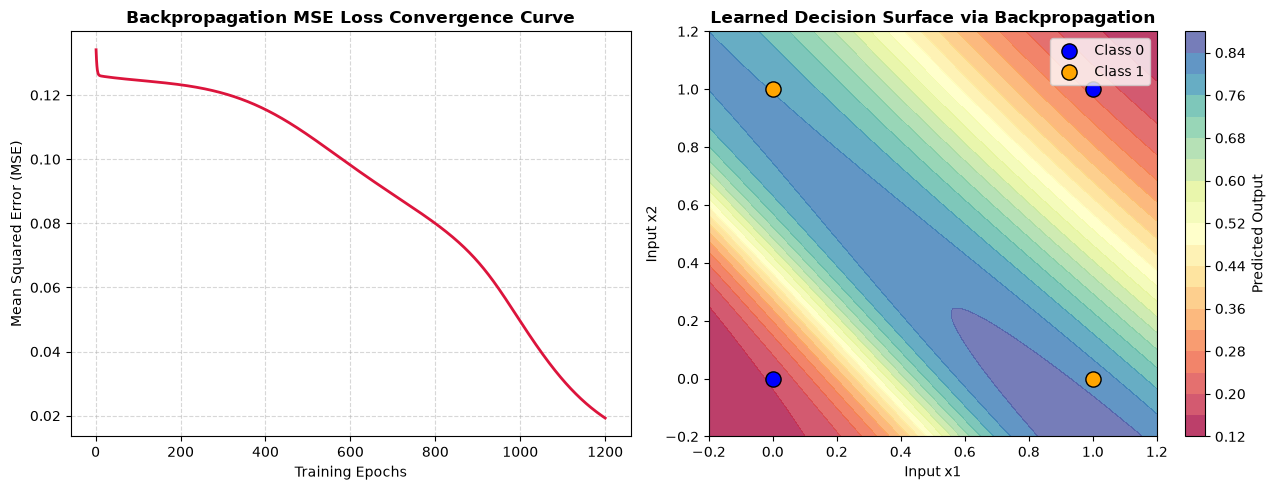


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_2_Neural_Networks/../output_plots/mod2_ex07_backpropagation.png
[✓] Practical 2.7 completed successfully.



In [8]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -25, 25)))

def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1.0 - s)

class BackpropagationNN:
    def __init__(self, input_dim=2, hidden_dim=4, output_dim=1, lr=0.5):
        self.lr = lr
        np.random.seed(42)
        # Initialize weights with Xavier/Glorot scaling
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))
        self.loss_history = []

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, y_pred):
        m = X.shape[0]
        # Output layer error
        delta2 = (y_pred - y) * sigmoid_prime(self.z2)
        dW2 = np.dot(self.a1.T, delta2) / m
        db2 = np.sum(delta2, axis=0, keepdims=True) / m

        # Hidden layer error
        delta1 = np.dot(delta2, self.W2.T) * sigmoid_prime(self.z1)
        dW1 = np.dot(X.T, delta1) / m
        db1 = np.sum(delta1, axis=0, keepdims=True) / m

        # Parameter update
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

        # Mean Squared Error Loss
        mse = 0.5 * np.mean((y - y_pred) ** 2)
        return mse

    def train(self, X, y, epochs=1000):
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = self.backward(X, y, y_pred)
            self.loss_history.append(loss)
            if (epoch + 1) % 200 == 0:
                print(f"Epoch {epoch+1:4d} | MSE Loss = {loss:.6f}")

def run_practical_2_7():
    print("=" * 60)
    print("PRACTICAL 2.7: Backpropagation Algorithm from Scratch")
    print("=" * 60)

    # XOR Dataset
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y = np.array([[0], [1], [1], [0]])

    nn = BackpropagationNN(input_dim=2, hidden_dim=4, output_dim=1, lr=1.5)
    nn.train(X, y, epochs=1200)

    final_preds = nn.forward(X)
    print("\nTrained Network Predictions on XOR:")
    print(f"{'x1':^5} | {'x2':^5} | {'y_true':^8} | {'y_pred':^12} | {'Class':^8}")
    print("-" * 46)
    for i in range(4):
        p = float(final_preds[i, 0])
        print(f"{X[i, 0]:^5} | {X[i, 1]:^5} | {y[i, 0]:^8} | {p:^12.4f} | {round(p):^8}")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Plot 1: Loss Curve
    ax1.plot(range(1, len(nn.loss_history) + 1), nn.loss_history, 'crimson', linewidth=2)
    ax1.set_title("Backpropagation MSE Loss Convergence Curve", fontweight='bold')
    ax1.set_xlabel("Training Epochs")
    ax1.set_ylabel("Mean Squared Error (MSE)")
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Plot 2: Decision Surface
    x_span = np.linspace(-0.2, 1.2, 100)
    y_span = np.linspace(-0.2, 1.2, 100)
    XX, YY = np.meshgrid(x_span, y_span)
    grid = np.c_[XX.ravel(), YY.ravel()]
    ZZ = nn.forward(grid).reshape(XX.shape)

    contour = ax2.contourf(XX, YY, ZZ, levels=20, cmap='Spectral', alpha=0.8)
    fig.colorbar(contour, ax=ax2, label='Predicted Output')
    ax2.scatter([0, 1], [0, 1], c='blue', s=120, edgecolors='k', label='Class 0')
    ax2.scatter([0, 1], [1, 0], c='orange', s=120, edgecolors='k', label='Class 1')
    ax2.set_title("Learned Decision Surface via Backpropagation", fontweight='bold')
    ax2.set_xlabel("Input x1")
    ax2.set_ylabel("Input x2")
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod2_ex07_backpropagation.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 2.7 completed successfully.\n")

if True:
    run_practical_2_7()

## Practical 8: Practical 2.8: Training a Neural Network Model on a Dataset Using Keras

```
Practical 2.8: Training a Neural Network Model on a Dataset Using Keras
Course: Soft Computing (EL1) - STDA2102 | Module 2: Artificial Neural Networks

Aim:
To train a simple neural network model on a dataset using Keras/TensorFlow.

Theory:
Supervised training of neural networks on real datasets involves:
1. Data Preprocessing: Feature normalization (Z-score scaling) and categorical one-hot encoding.
2. Architecture Design: Selecting appropriate layer depth, width, and activation functions.
3. Loss Function & Optimizer: Cross-Entropy loss for classification with adaptive gradient methods (Adam).
4. Validation Monitoring: Tracking training loss vs. validation loss over epochs to detect overfitting.
```

PRACTICAL 2.8: Keras Model Training on Iris Dataset
Dataset: Iris (150 samples, 4 features, 3 classes)

--- Model Architecture ---


Model: "Iris_Classification_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_hidden1 (Dense)           │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden2 (Dense)           │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Dense)          │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)


Final Test Set Loss:     1.0687
Final Test Set Accuracy: 89.47%



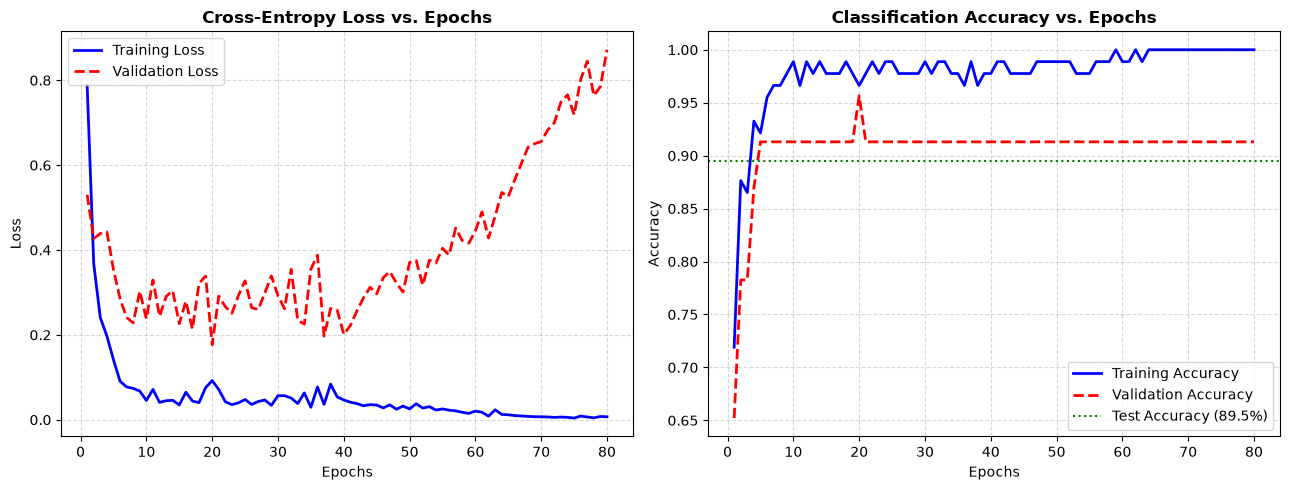

[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_2_Neural_Networks/../output_plots/mod2_ex08_train_model_keras.png
[✓] Practical 2.8 completed successfully.



In [9]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import keras
from keras import layers

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def run_practical_2_8():
    print("=" * 60)
    print("PRACTICAL 2.8: Keras Model Training on Iris Dataset")
    print("=" * 60)

    # 1. Load Dataset
    iris = load_iris()
    X, y = iris.data, iris.target
    feature_names = iris.feature_names
    target_names = iris.target_names

    print(f"Dataset: Iris ({len(X)} samples, {X.shape[1]} features, {len(target_names)} classes)")

    # 2. Train-Test Split & Feature Normalization
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 3. Model Architecture
    model = keras.Sequential([
        layers.Input(shape=(4,)),
        layers.Dense(16, activation='relu', name='dense_hidden1'),
        layers.Dense(8, activation='relu', name='dense_hidden2'),
        layers.Dense(3, activation='softmax', name='output_softmax')
    ], name="Iris_Classification_MLP")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.03),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print("\n--- Model Architecture ---")
    model.summary()

    # 4. Train Model
    epochs = 80
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=16,
        verbose=0
    )

    # 5. Evaluate on Test Set
    test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"\nFinal Test Set Loss:     {test_loss:.4f}")
    print(f"Final Test Set Accuracy: {test_acc * 100.0:.2f}%\n")

    # 6. Visualization: Training & Validation Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Loss Curves
    ax1.plot(range(1, epochs + 1), history.history['loss'], 'b-', linewidth=2, label='Training Loss')
    ax1.plot(range(1, epochs + 1), history.history['val_loss'], 'r--', linewidth=2, label='Validation Loss')
    ax1.set_title("Cross-Entropy Loss vs. Epochs", fontweight='bold')
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend()

    # Accuracy Curves
    ax2.plot(range(1, epochs + 1), history.history['accuracy'], 'b-', linewidth=2, label='Training Accuracy')
    ax2.plot(range(1, epochs + 1), history.history['val_accuracy'], 'r--', linewidth=2, label='Validation Accuracy')
    ax2.axhline(test_acc, color='green', linestyle=':', label=f'Test Accuracy ({test_acc*100:.1f}%)')
    ax2.set_title("Classification Accuracy vs. Epochs", fontweight='bold')
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Accuracy")
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod2_ex08_train_model_keras.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 2.8 completed successfully.\n")

if True:
    run_practical_2_8()

## Practical 9: Practical 2.9: Evaluation Metrics for Neural Networks

```
Practical 2.9: Evaluation Metrics for Neural Networks
Course: Soft Computing (EL1) - STDA2102 | Module 2: Artificial Neural Networks

Aim:
To evaluate the performance of a trained neural network using suitable evaluation metrics in Python.

Theory:
For binary and multi-class neural classifiers, performance is evaluated using:
1. Confusion Matrix: Contingency table of actual vs. predicted labels (TP, FP, TN, FN).
2. Accuracy: (TP + TN) / (TP + TN + FP + FN)
3. Precision (Positive Predictive Value): TP / (TP + FP)
4. Recall (Sensitivity / Hit Rate): TP / (TP + FN)
5. F1-Score: Harmonic mean of precision and recall: 2 * (Precision * Recall) / (Precision + Recall)
6. ROC Curve (Receiver Operating Characteristic): Plots True Positive Rate (Sensitivity)
   against False Positive Rate (1 - Specificity) across decision thresholds.
7. AUC (Area Under the ROC Curve): Overall separability metric (1.0 = perfect, 0.5 = random guess).
```

PRACTICAL 2.9: Neural Network Performance Evaluation Metrics



--- Quantitative Evaluation Summary ---
True Positives (TP):    84 | False Positives (FP):    4
True Negatives (TN):   197 | False Negatives (FN):   15
Accuracy:   93.67%
Precision:  0.9545
Recall:     0.8485
F1-Score:   0.8984
ROC-AUC:    0.9845

Detailed Classification Report:
                    precision    recall  f1-score   support

Class 0 (Negative)       0.93      0.98      0.95       201
Class 1 (Positive)       0.95      0.85      0.90        99

          accuracy                           0.94       300
         macro avg       0.94      0.91      0.93       300
      weighted avg       0.94      0.94      0.94       300



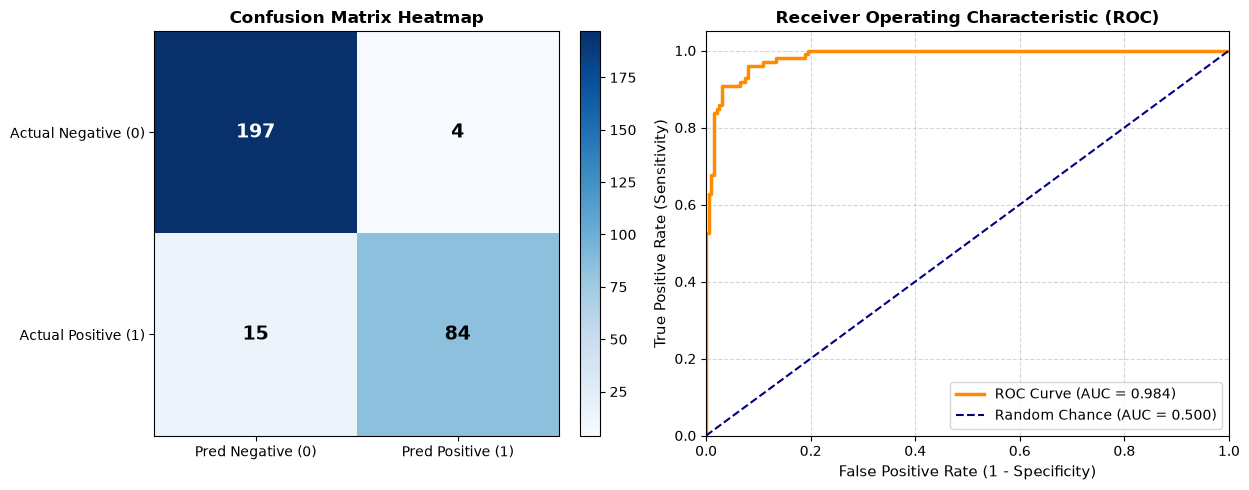

[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_2_Neural_Networks/../output_plots/mod2_ex09_evaluation_metrics.png
[✓] Practical 2.9 completed successfully.



In [10]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve)

import keras
from keras import layers

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def run_practical_2_9():
    print("=" * 60)
    print("PRACTICAL 2.9: Neural Network Performance Evaluation Metrics")
    print("=" * 60)

    # 1. Generate Realistic Imbalanced Dataset
    X, y = make_classification(n_samples=1000, n_features=10, n_informative=7,
                               weights=[0.7, 0.3], random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # 2. Train Neural Classifier
    model = keras.Sequential([
        layers.Input(shape=(10,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)

    # 3. Compute Predictions
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    # 4. Compute Metrics
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_prob)

    print("\n--- Quantitative Evaluation Summary ---")
    print(f"True Positives (TP):  {tp:4d} | False Positives (FP): {fp:4d}")
    print(f"True Negatives (TN):  {tn:4d} | False Negatives (FN): {fn:4d}")
    print(f"Accuracy:   {accuracy * 100.0:.2f}%")
    print(f"Precision:  {precision:.4f}")
    print(f"Recall:     {recall:.4f}")
    print(f"F1-Score:   {f1:.4f}")
    print(f"ROC-AUC:    {roc_auc:.4f}\n")

    print("Detailed Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Class 0 (Negative)', 'Class 1 (Positive)']))

    # 5. Visualization: Confusion Matrix & ROC Curve
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Confusion Matrix Heatmap
    im = ax1.imshow(cm, cmap='Blues', interpolation='nearest')
    ax1.set_title("Confusion Matrix Heatmap", fontweight='bold')
    ax1.set_xticks([0, 1])
    ax1.set_yticks([0, 1])
    ax1.set_xticklabels(['Pred Negative (0)', 'Pred Positive (1)'])
    ax1.set_yticklabels(['Actual Negative (0)', 'Actual Positive (1)'])
    plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

    # Annotate values
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax1.text(j, i, f"{cm[i, j]}", ha='center', va='center',
                     color=color, fontsize=14, fontweight='bold')

    # ROC Curve
    ax2.plot(fpr, tpr, color='darkorange', linewidth=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
    ax2.plot([0, 1], [0, 1], color='navy', linestyle='--', linewidth=1.5, label='Random Chance (AUC = 0.500)')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
    ax2.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
    ax2.set_title('Receiver Operating Characteristic (ROC)', fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc="lower right")

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod2_ex09_evaluation_metrics.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 2.9 completed successfully.\n")

if True:
    run_practical_2_9()

## Practical 10: Practical 2.10: Complete End-to-End ANN-Based Classification System

```
Practical 2.10: Complete End-to-End ANN-Based Classification System
Course: Soft Computing (EL1) - STDA2102 | Module 2: Artificial Neural Networks

Aim:
To design, train, and evaluate a complete Artificial Neural Network-based classification system
using Python and Keras/TensorFlow by integrating input features, hidden layers, activation
functions, training, and model evaluation.

Theory:
A production-grade ANN classification pipeline consists of 6 integrated engineering stages:
1. Problem Definition & Data Ingestion: Breast Cancer Diagnostic dataset (569 samples, 30 clinical features).
2. Data Preprocessing & Leakage Prevention: Stratified train/validation/test partitioning and StandardScaler.
3. Architecture Engineering: Multilayer Deep Feedforward Network with Dense layers, Batch Normalization,
   Dropout regularization (preventing co-adaptation of neurons), and He-normal initialization.
4. Optimization & Regularization: Adam optimizer with learning rate scheduling and Early Stopping.
5. Model Training: Minibatch gradient updates across training epochs with validation tracking.
6. Multi-Metric Clinical Evaluation: Accuracy, Precision, Recall/Sensitivity, Specificity, ROC-AUC, Confusion Matrix.
```

PRACTICAL 2.10: Complete End-to-End ANN Classification System
Dataset: Wisconsin Breast Cancer Diagnostic
Features: 30 clinical biometric features | Total Samples: 569
Target Classes: malignant (0) vs. benign (1)
Split distribution: Train=397, Validation=86, Test=86

--- ANN Architecture Specification ---


Model: "End_to_End_Clinical_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Dense_1 (Dense)          │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Dense_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Dense_3 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Diagnostic_Output (Dense)       │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)


Training completed in 67 epochs (Early stopping active).

--- Final Test Evaluation Results ---
Test Accuracy:  94.19%
Test Loss:      0.3501
Sensitivity:    92.59% (Recall for Benign)
Specificity:    96.88% (True Malignant Rate)
ROC-AUC Score:  0.9890

Detailed Classification Report:
              precision    recall  f1-score   support

   Malignant       0.89      0.97      0.93        32
      Benign       0.98      0.93      0.95        54

    accuracy                           0.94        86
   macro avg       0.93      0.95      0.94        86
weighted avg       0.95      0.94      0.94        86



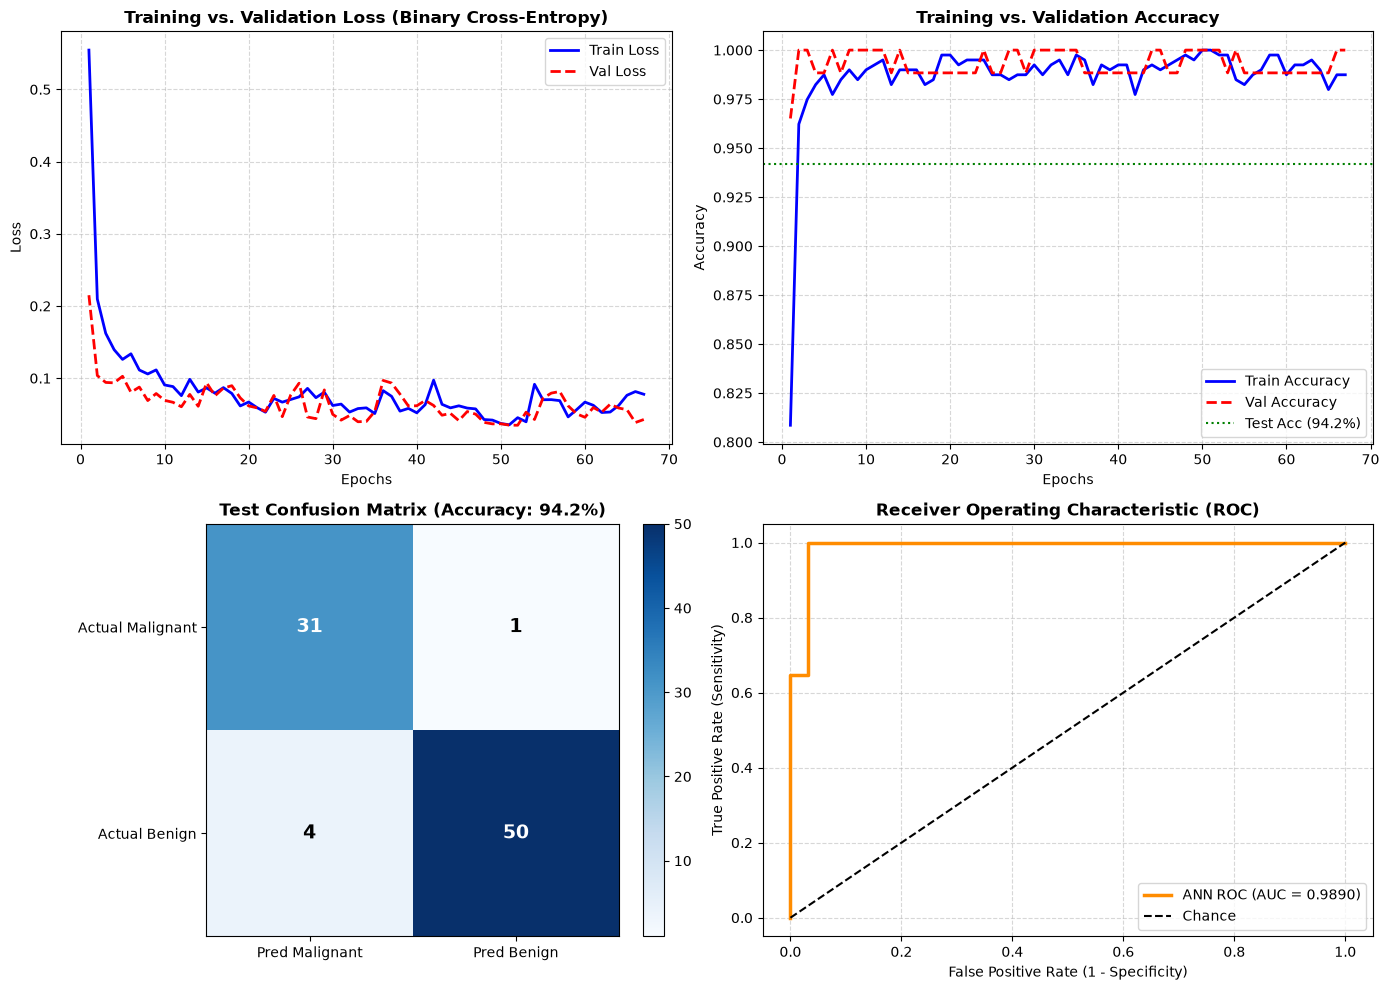

[✓] Dashboard saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_2_Neural_Networks/../output_plots/mod2_ex10_complete_ann_system.png
[✓] Practical 2.10 completed successfully.



In [11]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc)

import keras
from keras import layers, regularizers

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def run_practical_2_10():
    print("=" * 60)
    print("PRACTICAL 2.10: Complete End-to-End ANN Classification System")
    print("=" * 60)

    # 1. Dataset Ingestion
    cancer = load_breast_cancer()
    X, y = cancer.data, cancer.target
    feature_names = cancer.feature_names
    target_names = cancer.target_names  # ['malignant', 'benign']

    print(f"Dataset: Wisconsin Breast Cancer Diagnostic")
    print(f"Features: {X.shape[1]} clinical biometric features | Total Samples: {X.shape[0]}")
    print(f"Target Classes: {target_names[0]} (0) vs. {target_names[1]} (1)")

    # 2. Preprocessing & Partitioning (70% Train, 15% Val, 15% Test)
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    print(f"Split distribution: Train={len(X_train)}, Validation={len(X_val)}, Test={len(X_test)}")

    # 3. Model Architecture with Dropout Regularization
    model = keras.Sequential([
        layers.Input(shape=(X.shape[1],), name="Biometric_Input_Layer"),
        layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001), name="Hidden_Dense_1"),
        layers.Dropout(0.3, name="Dropout_1"),
        layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.001), name="Hidden_Dense_2"),
        layers.Dropout(0.2, name="Dropout_2"),
        layers.Dense(16, activation="relu", name="Hidden_Dense_3"),
        layers.Dense(1, activation="sigmoid", name="Diagnostic_Output")
    ], name="End_to_End_Clinical_ANN")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.005),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    print("\n--- ANN Architecture Specification ---")
    model.summary()

    # 4. Model Training with Early Stopping
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
    ]

    epochs = 80
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=32,
        callbacks=callbacks,
        verbose=0
    )

    actual_epochs = len(history.history['loss'])
    print(f"\nTraining completed in {actual_epochs} epochs (Early stopping active).")

    # 5. Model Evaluation on Unseen Test Partition
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    print("\n--- Final Test Evaluation Results ---")
    print(f"Test Accuracy:  {test_acc * 100.0:.2f}%")
    print(f"Test Loss:      {test_loss:.4f}")
    print(f"Sensitivity:    {(tp / (tp + fn)) * 100.0:.2f}% (Recall for Benign)")
    print(f"Specificity:    {(tn / (tn + fp)) * 100.0:.2f}% (True Malignant Rate)")
    print(f"ROC-AUC Score:  {roc_auc:.4f}\n")

    print("Detailed Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

    # 6. Visualization Dashboard (4-panel diagnostic figure)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Panel 1: Loss History
    axes[0, 0].plot(range(1, actual_epochs + 1), history.history['loss'], 'b-', linewidth=2, label='Train Loss')
    axes[0, 0].plot(range(1, actual_epochs + 1), history.history['val_loss'], 'r--', linewidth=2, label='Val Loss')
    axes[0, 0].set_title("Training vs. Validation Loss (Binary Cross-Entropy)", fontweight='bold')
    axes[0, 0].set_xlabel("Epochs")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].grid(True, linestyle='--', alpha=0.5)
    axes[0, 0].legend()

    # Panel 2: Accuracy History
    axes[0, 1].plot(range(1, actual_epochs + 1), history.history['accuracy'], 'b-', linewidth=2, label='Train Accuracy')
    axes[0, 1].plot(range(1, actual_epochs + 1), history.history['val_accuracy'], 'r--', linewidth=2, label='Val Accuracy')
    axes[0, 1].axhline(test_acc, color='green', linestyle=':', label=f'Test Acc ({test_acc*100:.1f}%)')
    axes[0, 1].set_title("Training vs. Validation Accuracy", fontweight='bold')
    axes[0, 1].set_xlabel("Epochs")
    axes[0, 1].set_ylabel("Accuracy")
    axes[0, 1].grid(True, linestyle='--', alpha=0.5)
    axes[0, 1].legend()

    # Panel 3: Confusion Matrix
    im = axes[1, 0].imshow(cm, cmap='Blues')
    axes[1, 0].set_title(f"Test Confusion Matrix (Accuracy: {test_acc*100:.1f}%)", fontweight='bold')
    axes[1, 0].set_xticks([0, 1])
    axes[1, 0].set_yticks([0, 1])
    axes[1, 0].set_xticklabels(['Pred Malignant', 'Pred Benign'])
    axes[1, 0].set_yticklabels(['Actual Malignant', 'Actual Benign'])
    for i in range(2):
        for j in range(2):
            axes[1, 0].text(j, i, f"{cm[i, j]}", ha='center', va='center',
                            color='white' if cm[i, j] > cm.max()/2 else 'black',
                            fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)

    # Panel 4: ROC Curve
    axes[1, 1].plot(fpr, tpr, color='darkorange', linewidth=2.5, label=f'ANN ROC (AUC = {roc_auc:.4f})')
    axes[1, 1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Chance')
    axes[1, 1].set_title("Receiver Operating Characteristic (ROC)", fontweight='bold')
    axes[1, 1].set_xlabel("False Positive Rate (1 - Specificity)")
    axes[1, 1].set_ylabel("True Positive Rate (Sensitivity)")
    axes[1, 1].grid(True, linestyle='--', alpha=0.5)
    axes[1, 1].legend(loc="lower right")

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod2_ex10_complete_ann_system.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"[✓] Dashboard saved successfully to: {plot_path}")
    print("[✓] Practical 2.10 completed successfully.\n")

if True:
    run_practical_2_10()